Задание Light

Выполните подробную работу с параметрами словаря и формированием гиперпараметров нейронной сети. Создайте 9 нейросетей с различными гиперпараметрами (см. пунтк 2 и 3)

 Для этого необходимо:

  1. Воссоздать ноутбук, аналогичный ноутбуку практической части №1, загрузив при этом необходимую нам базу (код уже доступен в ноутбуке).

  2. Задать в ноутбуке следующие параметры для размера словаря, ширины окна и шага:

    - Размер словаря - от 10000 до 20000 (выбрать меньшее значение диапазона, если будет перегрузка ОЗУ и перезапуск подключения к Colaboratory)
    - Ширина окна - от 1000 до 2000
    - Шаг - от 100 до 500 (на обучение лучше влияет наименьший шаг, но это может перегрузить ОЗУ).

  3. Создать архитектуру сети и задать гиперпараметры. Можно воспользоваться шаблоном:
  
   - Добавьте модель прямого распространения **Sequential()**
   - Добавьте один или несколько полносвязных (**Dense**) слоёв
   - Добавьте слои **Dropout()** и **BatchNormalization()**
   - Добавьте выходной полносвязный слой с количеством нейронов, соответствующим количеству классов (число писателей)
  
   Напомним, что точность сети можно проверить по значению показателя 'val_accuracy' на конце каждой эпохи.
   

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Запись в файлы и чтение из файлов структур данных Python
import pickle

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'
'(О. Генри) Обучающая_50 вместе.txt'
'(О. Генри) Тестовая_20 вместе.txt'
'(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Стругацкие) Обучающая_5 вместе.txt'
'(Стругацкие) Тестовая_2 вместе.txt'


In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

# Загрузка датасета. Добавляются имена классов и соответствующие тексты.
# Все тексты преобразуются в строку и объединяются для каждого класса и выборки
CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    # Выделение имени класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатывается
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        # Проверка типа выборки в имени файла
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатывается
        if is_train or is_test:
            # Добавление нового класса, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                # Инициализация соответствующих классу строк текста
                text_train.append('')
                text_test.append('')

            # Поиск индекса класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                # Загрузка содержимого файла в строку
                text = f.read()
            # Определение выборки, куда будет добавлено содержимое
            subset = text_train if is_train else text_test
            # Добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе

<>:14: SyntaxWarning: invalid escape sequence '\('
<>:14: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_5738/1261361779.py:14: SyntaxWarning: invalid escape sequence '\('
  m = re.match('\((.+)\) (\S+)_', file_name)


In [ ]:
# класс для упрощения подготовки данных
class DataProcessor:
  def __init__(self, vocab_size, win_size, win_hop):
    self.vocab_size = vocab_size # размер словаря
    self.win_size = win_size # размер окна
    self.win_hop = win_hop# шаг окна
    self.tokenizer = None # хранение токенайзера

  # нарезка одного текста на окна
  def split_sequence(self, sequence):
    result = [] # список для хранения полученных окон

    # идем по тексту с заданным шагом и берем куски нужного размера
    for i in range(0, len(sequence) - self.win_size + 1, self.win_hop):
      result.append(sequence[i:i + self.win_size])

    return result # список окон

  # нарезка всех текстов и создание меток классов
  def vectorize_sequence(self, seq_list):
    x = [] # список для обучающих или проверочных примеров
    y = [] # список для правильных ответов

    # количество классов равно количеству авторов
    class_count = len(seq_list)

    # перебор каждого класса отдельно
    for class_index in range(class_count):
      windows = self.split_sequence(seq_list[class_index])

      x += windows
      y += [utils.to_categorical(class_index, class_count)] * len(windows)

    # перевод списков в массивы numpy
    return np.array(x), np.array(y)

  # полная подготовка данных
  def prepare(self, text_train, text_test):
    # создание токенайзера
    self.tokenizer = Tokenizer(num_words=self.vocab_size, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)

    # обучение токенайзера
    self.tokenizer.fit_on_texts(text_train)

    # перевод обучающих и проверочных текстов в последовательности чисел
    seq_train = self.tokenizer.texts_to_sequences(text_train)
    seq_test = self.tokenizer.texts_to_sequences(text_test)

    # обрезка последовательностей на окна
    x_train, y_train = self.vectorize_sequence(seq_train)
    x_test, y_test = self.vectorize_sequence(seq_test)

    # перевод окна в Bag of Words
    x_train_01 = self.tokenizer.sequences_to_matrix(x_train.tolist(), mode='binary')
    x_test_01 = self.tokenizer.sequences_to_matrix(x_test.tolist(), mode='binary')

    # вывод текущих параметров
    print('VOCAB_SIZE:', self.vocab_size)
    print('WIN_SIZE:', self.win_size)
    print('WIN_HOP:', self.win_hop)
    print('x_train_01:', x_train_01.shape)
    print('y_train:', y_train.shape)
    print('x_test_01:', x_test_01.shape)
    print('y_test:', y_test.shape)

    return x_train_01, y_train, x_test_01, y_test

# создание модели
def create_model(input_dim, class_count):
  model = Sequential()

  model.add(Dense(256, input_dim=input_dim, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.3))

  model.add(Dense(128, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.3))

  model.add(Dense(class_count, activation='softmax'))

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  return model

def plot_history(history, vocab_size, win_size, win_hop):
  # график точности
  plt.figure(figsize=(8, 5))
  plt.plot(history.history['accuracy'], label='Точность на обучении')
  plt.plot(history.history['val_accuracy'], label='Точность на проверке')
  plt.title(
    f'График точности\n'
    f'VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}'
  )
  plt.xlabel('Эпоха')
  plt.ylabel('Точность')
  plt.legend()
  plt.grid(True)
  plt.show()

  # график ошибки
  plt.figure(figsize=(8, 5))
  plt.plot(history.history['loss'], label='Ошибка на обучении')
  plt.plot(history.history['val_loss'], label='Ошибка на проверке')
  plt.title(
    f'График ошибки\n'
    f'VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}'
  )
  plt.xlabel('Эпоха')
  plt.ylabel('Ошибка')
  plt.legend()
  plt.grid(True)
  plt.show()

VOCAB_SIZE: 10000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_01: (18508, 10000)
y_train: (18508, 6)
x_test_01: (7031, 10000)
y_test: (7031, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9740 - loss: 0.0869 - val_accuracy: 0.8229 - val_loss: 0.5561
Epoch 2/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8737 - val_loss: 0.3829
Epoch 3/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 8.2467e-04 - val_accuracy: 0.8792 - val_loss: 0.3515
Epoch 4/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 4.7251e-04 - val_accuracy: 0.8858 - val_loss: 0.3350
Epoch 5/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 3.3753e-04 - val_accuracy: 0.8848 - val_loss: 0.3358
Epoch 6/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 2.4218e-04 - val_accuracy: 0.8858 - val_loss: 0.3331
Epoch 7/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 1.7011e-04 - val_accuracy: 0.8878 - val_loss: 0.3301
Epoch 8/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 1.

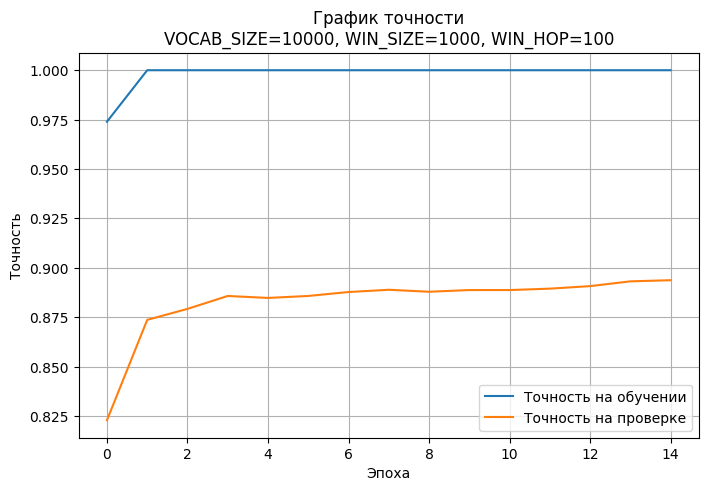

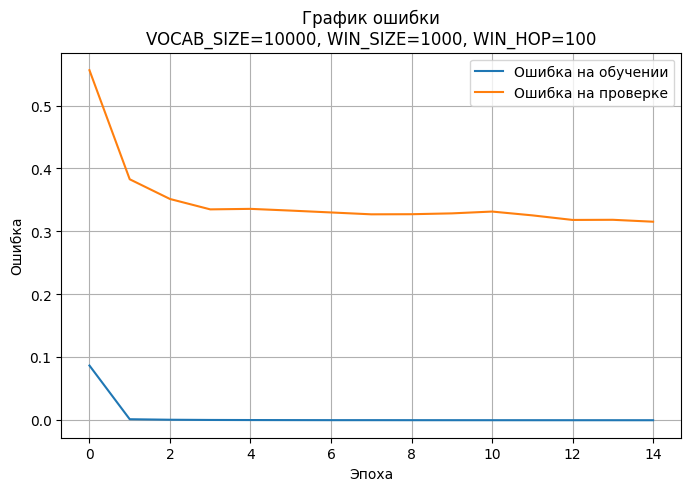

Лучшая точность: 0.8937562108039856


In [ ]:
results = [] # таблица с результатами

VOCAB_SIZE = 10000
WIN_SIZE = 1000
WIN_HOP = 100

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 10000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_01: (7391, 10000)
y_train: (7391, 6)
x_test_01: (2802, 10000)
y_test: (2802, 6)
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9490 - loss: 0.1748 - val_accuracy: 0.7698 - val_loss: 0.7474
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.8469 - val_loss: 0.5141
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9999 - loss: 0.0022 - val_accuracy: 0.8687 - val_loss: 0.4099
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8833 - val_loss: 0.3603
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 9.3909e-04 - val_accuracy: 0.8869 - val_loss: 0.3370
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 8.1635e-04 - val_accuracy: 0.8883 - val_loss: 0.3280
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 5.8927e-04 - val_acc

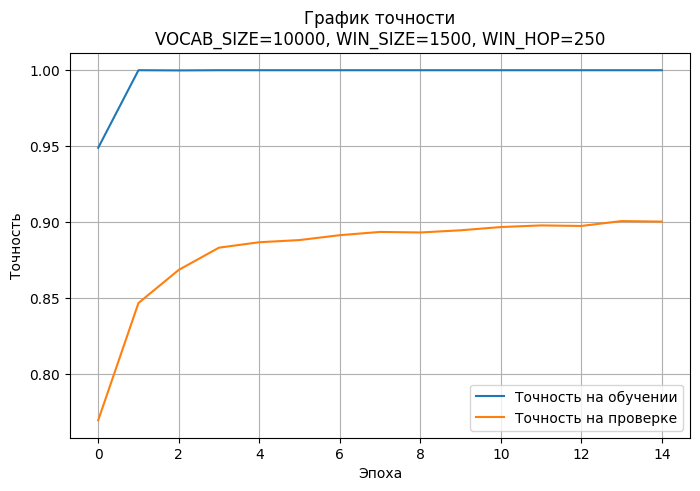

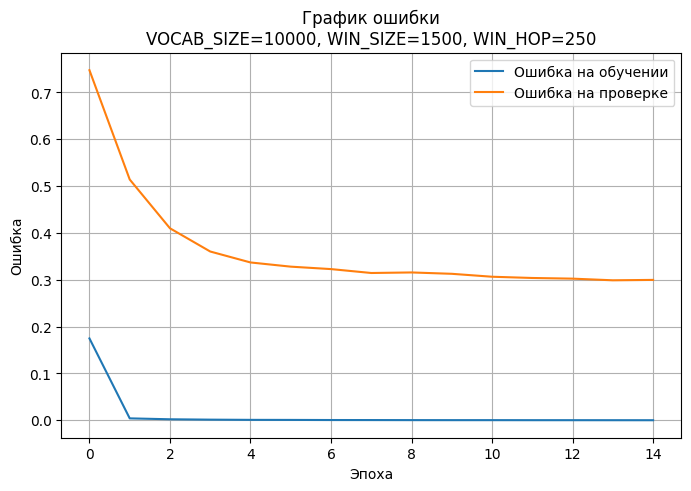

Лучшая точность: 0.9007851481437683


In [ ]:
VOCAB_SIZE = 10000
WIN_SIZE = 1500
WIN_HOP = 250

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 10000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_01: (3691, 10000)
y_train: (3691, 6)
x_test_01: (1396, 10000)
y_test: (1396, 6)
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.9130 - loss: 0.2740 - val_accuracy: 0.7264 - val_loss: 1.0126
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.7479 - val_loss: 0.7844
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.7858 - val_loss: 0.6196
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8360 - val_loss: 0.5112
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8689 - val_loss: 0.4389
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8811 - val_loss: 0.3868
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.898

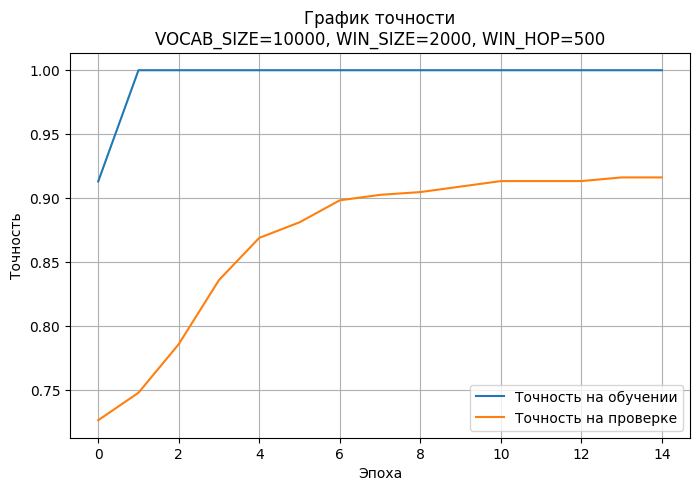

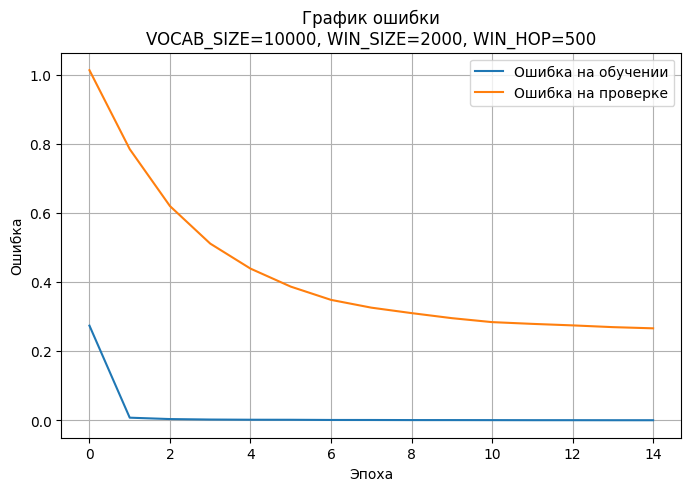

Лучшая точность: 0.9161891341209412


In [ ]:
VOCAB_SIZE = 10000
WIN_SIZE = 2000
WIN_HOP = 500

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 15000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_01: (18508, 15000)
y_train: (18508, 6)
x_test_01: (7031, 15000)
y_test: (7031, 6)
Epoch 1/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9755 - loss: 0.0810 - val_accuracy: 0.8586 - val_loss: 0.4856
Epoch 2/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8689 - val_loss: 0.3792
Epoch 3/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 1.0000 - loss: 7.5842e-04 - val_accuracy: 0.8784 - val_loss: 0.3444
Epoch 4/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 4.3923e-04 - val_accuracy: 0.8820 - val_loss: 0.3387
Epoch 5/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 3.1716e-04 - val_accuracy: 0.8845 - val_loss: 0.3250
Epoch 6/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 2.3482e-04 - val_accuracy: 0.8852 - val_loss: 0.3250
Epoch 7/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - 

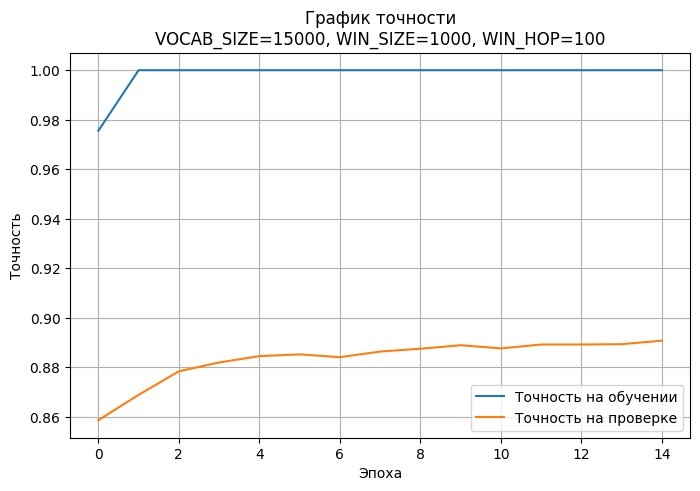

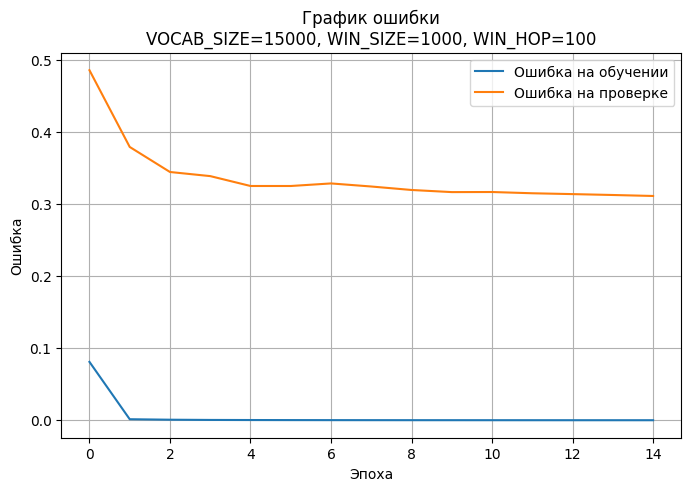

Лучшая точность: 0.8907694220542908


In [ ]:
VOCAB_SIZE = 15000
WIN_SIZE = 1000
WIN_HOP = 100

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 15000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_01: (7391, 15000)
y_train: (7391, 6)
x_test_01: (2802, 15000)
y_test: (2802, 6)
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9521 - loss: 0.1613 - val_accuracy: 0.7580 - val_loss: 0.7662
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.8544 - val_loss: 0.4887
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8858 - val_loss: 0.3773
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9022 - val_loss: 0.3266
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 8.2977e-04 - val_accuracy: 0.9083 - val_loss: 0.3034
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 6.7662e-04 - val_accuracy: 0.9101 - val_loss: 0.2900
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 6.0152e-04 - val_ac

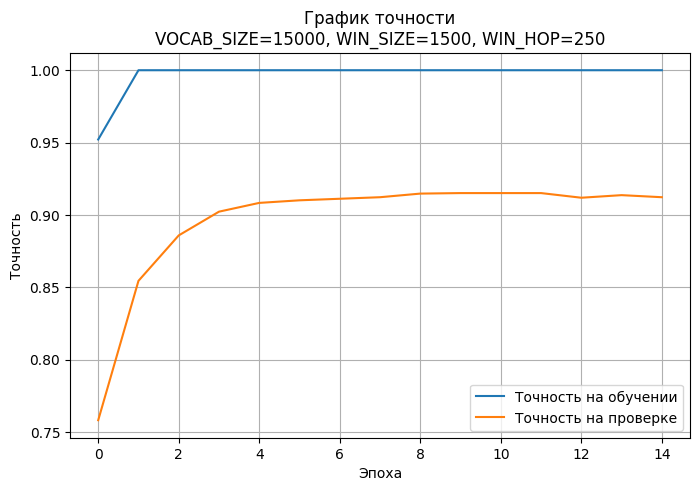

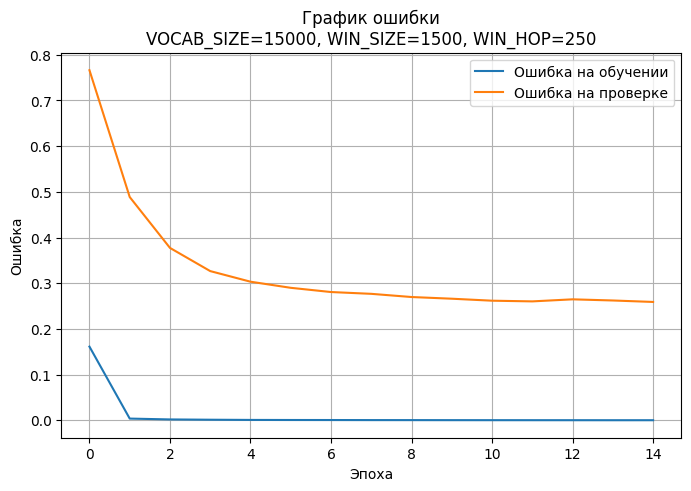

Лучшая точность: 0.9150606989860535


In [ ]:
VOCAB_SIZE = 15000
WIN_SIZE = 1500
WIN_HOP = 250

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 15000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_01: (3691, 15000)
y_train: (3691, 6)
x_test_01: (1396, 15000)
y_test: (1396, 6)
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.9228 - loss: 0.2817 - val_accuracy: 0.7056 - val_loss: 0.8621
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.7772 - val_loss: 0.6595
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.8245 - val_loss: 0.5331
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8503 - val_loss: 0.4585
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8660 - val_loss: 0.4022
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8832 - val_loss: 0.3630
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.

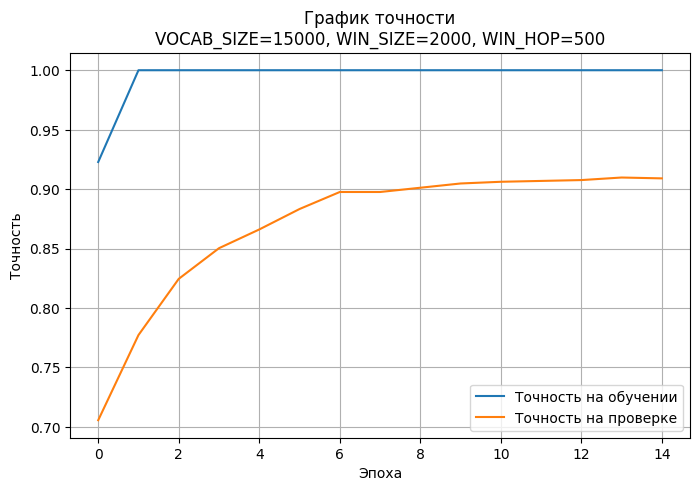

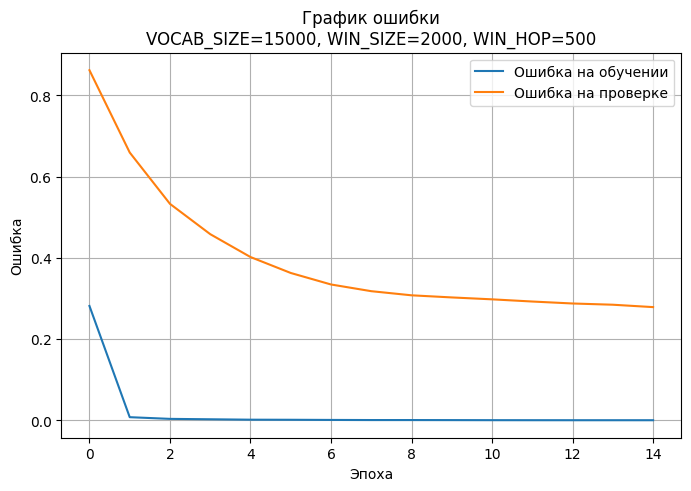

Лучшая точность: 0.9097421169281006


In [ ]:
VOCAB_SIZE = 15000
WIN_SIZE = 2000
WIN_HOP = 500

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 20000
WIN_SIZE: 1000
WIN_HOP: 100
x_train_01: (18508, 20000)
y_train: (18508, 6)
x_test_01: (7031, 20000)
y_test: (7031, 6)
Epoch 1/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9795 - loss: 0.0689 - val_accuracy: 0.8484 - val_loss: 0.5204
Epoch 2/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.8849 - val_loss: 0.3610
Epoch 3/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 5.4396e-04 - val_accuracy: 0.8906 - val_loss: 0.3335
Epoch 4/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 3.7341e-04 - val_accuracy: 0.8908 - val_loss: 0.3250
Epoch 5/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 1.0000 - loss: 2.4372e-04 - val_accuracy: 0.8926 - val_loss: 0.3196
Epoch 6/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 1.9382e-04 - val_accuracy: 0.8928 - val_loss: 0.3158
Epoch 7/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 -

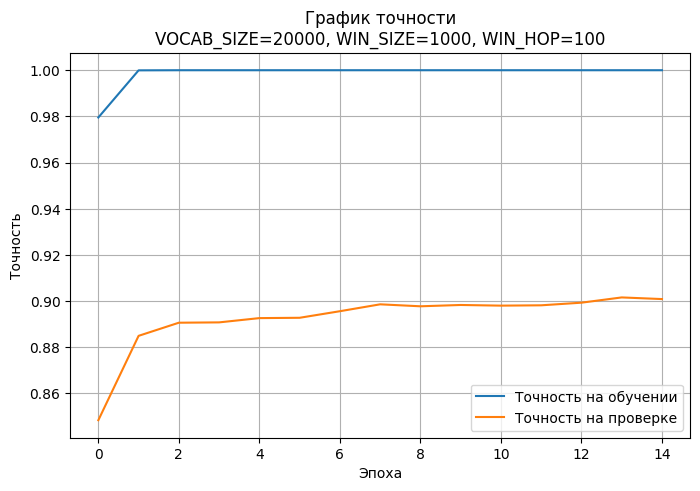

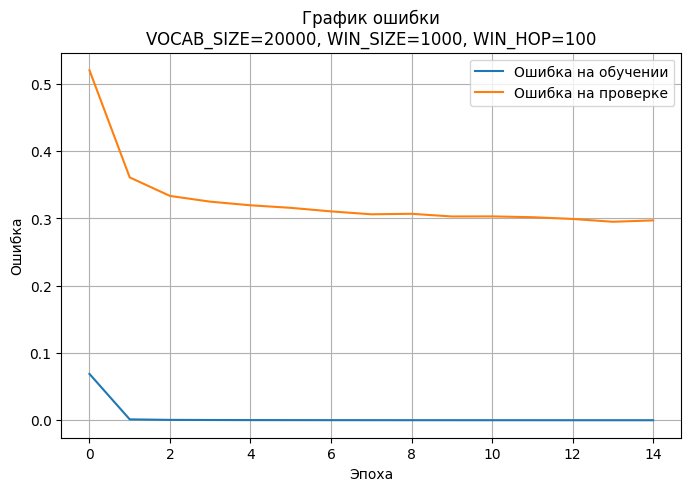

Лучшая точность: 0.9015787243843079


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 1000
WIN_HOP = 100

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 20000
WIN_SIZE: 1500
WIN_HOP: 250
x_train_01: (7391, 20000)
y_train: (7391, 6)
x_test_01: (2802, 20000)
y_test: (2802, 6)
Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9621 - loss: 0.1336 - val_accuracy: 0.7919 - val_loss: 0.7036
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8555 - val_loss: 0.5151
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8797 - val_loss: 0.4131
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8897 - val_loss: 0.3522
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 7.4449e-04 - val_accuracy: 0.9001 - val_loss: 0.3211
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 5.2091e-04 - val_accuracy: 0.9029 - val_loss: 0.3028
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 5.1774e-04 - val_a

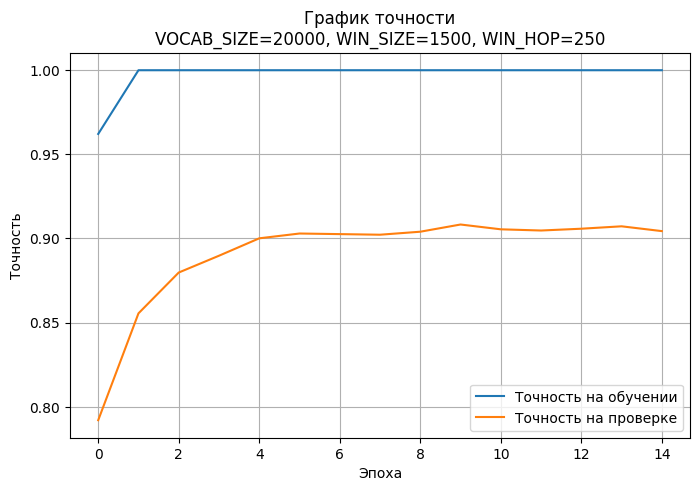

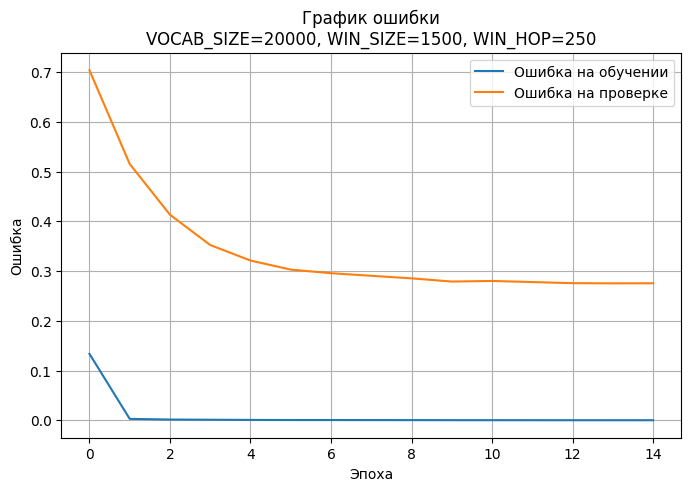

Лучшая точность: 0.9082797765731812


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 1500
WIN_HOP = 250

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

VOCAB_SIZE: 20000
WIN_SIZE: 2000
WIN_HOP: 500
x_train_01: (3691, 20000)
y_train: (3691, 6)
x_test_01: (1396, 20000)
y_test: (1396, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9293 - loss: 0.2310 - val_accuracy: 0.8711 - val_loss: 0.6302
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.8883 - val_loss: 0.4758
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9997 - loss: 0.0029 - val_accuracy: 0.8933 - val_loss: 0.4128
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8997 - val_loss: 0.3666
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9090 - val_loss: 0.3311
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9148 - val_loss: 0.3049
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 9.2143e-04 - val_accuracy: 0.9169 - val_loss: 0.2888
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 7.1302e-04 - val_accuracy: 0

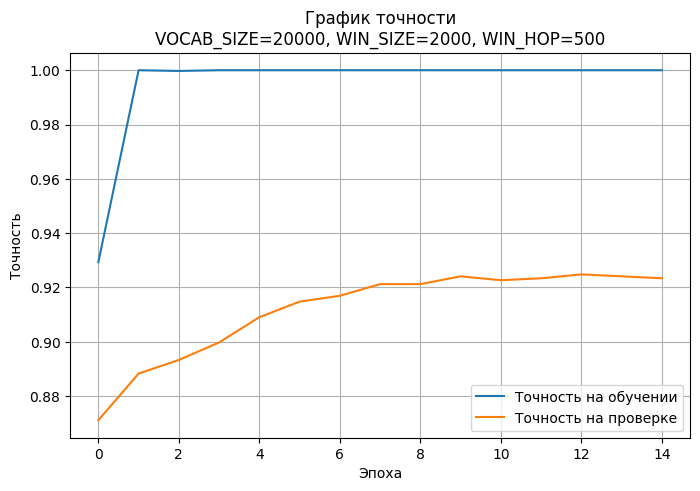

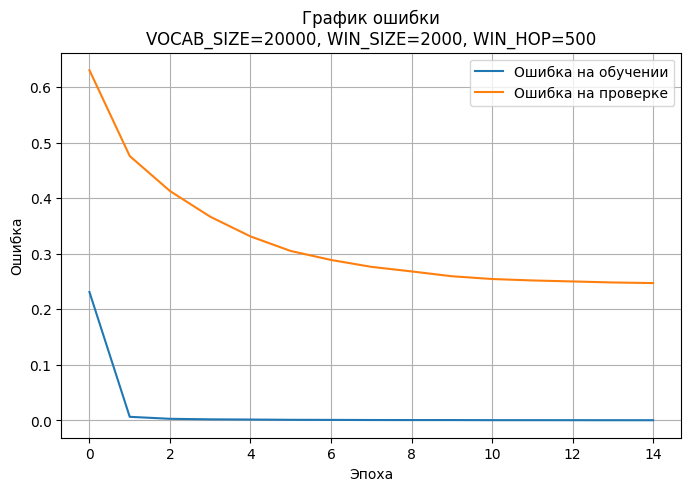

Лучшая точность: 0.9247850775718689


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 2000
WIN_HOP = 500

processor = DataProcessor(VOCAB_SIZE, WIN_SIZE, WIN_HOP)
x_train_01, y_train, x_test_01, y_test = processor.prepare(text_train, text_test)
model = create_model(input_dim=x_train_01.shape[1], class_count=len(CLASS_LIST))
history = model.fit(x_train_01, y_train, epochs=15, batch_size=128, validation_data=(x_test_01, y_test), verbose=1)

best_val_accuracy = max(history.history['val_accuracy'])

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

print('Лучшая точность:', best_val_accuracy)

results.append({
  'VOCAB_SIZE': VOCAB_SIZE,
  'WIN_SIZE': WIN_SIZE,
  'WIN_HOP': WIN_HOP,
  'Точность на обучении': history.history['accuracy'][-1],
  'Точность на проверке': history.history['val_accuracy'][-1],
  'Лучшая точность на проверке': max(history.history['val_accuracy']),
  'Ошибка на обучении': history.history['loss'][-1],
  'Ошибка на проверке': history.history['val_loss'][-1],
  'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

In [ ]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df

,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Точность на обучении,Точность на проверке,Лучшая точность на проверке,Ошибка на обучении,Ошибка на проверке,Лучшая ошибка на проверке
0,10000,1000,100,1.0,0.893756,0.893756,0.000048,0.315416,0.315416
1,10000,1500,250,1.0,0.900428,0.900785,0.000171,0.299746,0.298899
2,10000,2000,500,1.0,0.916189,0.916189,0.000442,0.266191,0.266191
3,15000,1000,100,1.0,0.890769,0.890769,0.000046,0.311168,0.311168
4,15000,1500,250,1.0,0.912206,0.915061,0.000189,0.259048,0.259048
5,15000,2000,500,1.0,0.909026,0.909742,0.000456,0.278912,0.278912
6,20000,1000,100,1.0,0.900868,0.901579,0.000034,0.297138,0.295096
7,20000,1500,250,1.0,0.904354,0.908280,0.000135,0.275424,0.275209
8,20000,2000,500,1.0,0.923352,0.924785,0.000338,0.247165,0.247165
